<a href="https://colab.research.google.com/github/minji25-hue/NVIDIA/blob/20250404/yolov8_picture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Using cached ultralytics-8.3.101-py3-none-any.whl.metadata (37 kB)
  Using cached ultralytics_thop-2.0.14-py3-none-any.whl.metadata (9.4 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
Using cached ultralytics-8.3.101-py3-none-any.whl (977 kB)
Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl (127.9 MB)
Using cached ultralytics_thop-2.0.14-py3-none-any.whl (26 kB)
  Attempting uninstall: nvidia-cudnn-cu12
    Found existing installation: nvidia-cudnn-cu12 9.3.0.75
    Uninstalling nvidia-cudnn-cu12-9.3.0.75:
      Successfully uninstalled nvidia-cudnn-cu12-9.3.0.75
  Attempting uninstall: nvidia-cusolver-cu12
    Found existing installation: nvidia-cusolver-cu12 11.6.3.83
    Uninstalling nvidia-cusolver-cu12-11.6.3.83:
      Suc

100%|██████████| 6.25M/6.25M [00:00<00:00, 71.4MB/s]



image 1/1 /content/1.jpg: 320x640 11 persons, 14 umbrellas, 4 handbags, 317.7ms
Speed: 16.4ms preprocess, 317.7ms inference, 35.3ms postprocess per image at shape (1, 3, 320, 640)
우산을 들고 있는 사람 수: 14


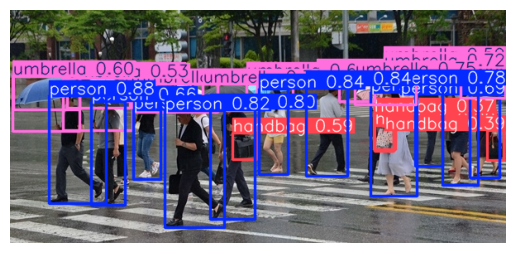

In [ ]:
# 필요한 라이브러리 설치 (YOLOv8 설치)
!pip install ultralytics

# YOLOv8 불러오기
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 모델 로드 (사전 학습된 YOLOv8 모델)
model = YOLO('yolov8n.pt')  # yolov8n.pt는 기본 제공되는 사전 학습된 모델입니다.

# 이미지 로드
image_path = '/content/1.jpg'  # 이미지 경로
image = cv2.imread(image_path)

# 객체 감지 실행
results = model(image_path)

# 감지된 객체 필터링 (우산만 선택)
umbrella_count = 0
for result in results:
    for box, class_id in zip(result.boxes.xyxy, result.boxes.cls):
        if model.names[int(class_id)] == 'umbrella':  # 클래스 이름이 'umbrella'인 경우
            umbrella_count += 1

# 결과 출력
print(f"우산을 들고 있는 사람 수: {umbrella_count}")

# 감지 결과 시각화
annotated_image = results[0].plot()  # 감지된 객체가 표시된 이미지 생성
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()